### Import packages

In [316]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Load Dataset

In [317]:
df = pd.read_csv("cars_data.csv")

### Check rows and columns in dataset

In [318]:
df.shape

(301, 9)

### Remove Duplicates from the dataset

In [319]:
df.drop_duplicates(inplace=True)

### Basic information of dataset

In [320]:
df.info()

<class 'pandas.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       299 non-null    str    
 1   Year           299 non-null    int64  
 2   Selling_Price  299 non-null    float64
 3   Present_Price  299 non-null    float64
 4   Kms_Driven     299 non-null    int64  
 5   Fuel_Type      299 non-null    str    
 6   Seller_Type    299 non-null    str    
 7   Transmission   299 non-null    str    
 8   Owner          299 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 23.4 KB


In [321]:
df.head(2)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0


In [322]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.567887,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


### Check Null Values

In [323]:
df.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

### Check column names

In [324]:
print(df.columns)

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')


In [325]:
df.head(2)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0


### Split data into input feature x and target label y

In [326]:
x = df[
    [
        'Year',
        'Present_Price',
        'Kms_Driven',
        'Fuel_Type',
        'Seller_Type',
        'Transmission',
        'Owner'
    ]
].copy()
y = df['Selling_Price'] 

In [327]:
y

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 299, dtype: float64

In [328]:
x

,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,5.59,27000,Petrol,Dealer,Manual,0
1,2013,9.54,43000,Diesel,Dealer,Manual,0
2,2017,9.85,6900,Petrol,Dealer,Manual,0
3,2011,4.15,5200,Petrol,Dealer,Manual,0
4,2014,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...
296,2016,11.60,33988,Diesel,Dealer,Manual,0
297,2015,5.90,60000,Petrol,Dealer,Manual,0
298,2009,11.00,87934,Petrol,Dealer,Manual,0
299,2017,12.50,9000,Diesel,Dealer,Manual,0


### Use LabelEncoder to convert categorical feature into numerical features

In [329]:
# from sklearn.preprocessing import LabelEncoder
# fuel_encoder  = LabelEncoder()
# transmission_encoder   = LabelEncoder()
# x['Fuel_Type'] = fuel_encoder.fit_transform(x['Fuel_Type'])
# x['Transmission'] = transmission_encoder.fit_transform(x['Transmission'])
from sklearn.preprocessing import LabelEncoder

fuel_encoder = LabelEncoder()
seller_encoder = LabelEncoder()
transmission_encoder = LabelEncoder()

x['Fuel_Type'] = fuel_encoder.fit_transform(x['Fuel_Type'])
x['Seller_Type'] = seller_encoder.fit_transform(x['Seller_Type'])
x['Transmission'] = transmission_encoder.fit_transform(x['Transmission'])

In [330]:
x

,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,5.59,27000,2,0,1,0
1,2013,9.54,43000,1,0,1,0
2,2017,9.85,6900,2,0,1,0
3,2011,4.15,5200,2,0,1,0
4,2014,6.87,42450,1,0,1,0
...,...,...,...,...,...,...,...
296,2016,11.60,33988,1,0,1,0
297,2015,5.90,60000,2,0,1,0
298,2009,11.00,87934,2,0,1,0
299,2017,12.50,9000,1,0,1,0


### Split the data in training and testing sets

In [331]:


from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)



### Scale values between range [0,1]

In [332]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_train_scale = scaler.fit_transform(x_train)
x_test_scale = scaler.transform(x_test)

In [333]:
x_train_scale

array([[0.85714286, 0.08452536, 0.08609882, ..., 0.        , 1.        ,
        0.        ],
       [0.35714286, 0.00281751, 0.00658824, ..., 1.        , 0.        ,
        0.        ],
       [0.71428571, 0.00205895, 0.14823529, ..., 1.        , 1.        ,
        0.        ],
       ...,
       [0.92857143, 0.01278717, 0.08235294, ..., 1.        , 1.        ,
        0.        ],
       [0.85714286, 0.10489814, 0.12752941, ..., 0.        , 1.        ,
        0.        ],
       [1.        , 0.01246207, 0.01694118, ..., 1.        , 1.        ,
        0.        ]], shape=(239, 7))

### Train the model

#### 1 - Linear Regression Model

In [334]:
from sklearn.linear_model import LinearRegression


lr_model = LinearRegression()
lr_model.fit(x_train_scale,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 4.8 ,40.72,-1.99,...,-1.29,-1.58, 0.7 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.119
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,7
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](7,)","[7.56,5.21,3.52,...,2.54,1.34,1.09]"


In [335]:
lr_pred =lr_model.predict(x_test_scale)



#### Plot scatter graph for Linear regression

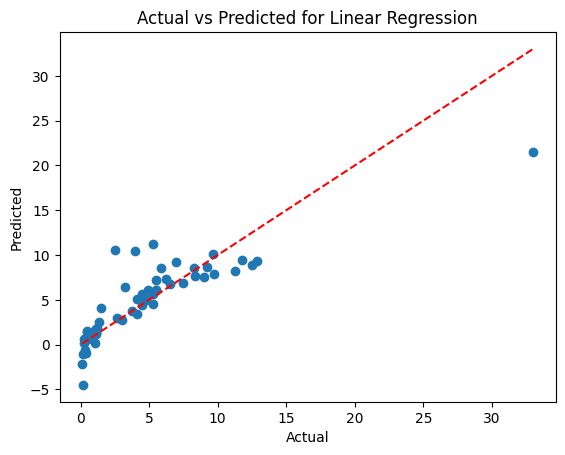

In [336]:
plt.scatter(y_test,lr_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted for Linear Regression')
plt.show()


In [337]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
R2_score = r2_score(y_test,lr_pred)
MAE = mean_absolute_error(y_test,lr_pred)
RMSE = np.sqrt(mean_squared_error(y_test,lr_pred))
print(f"R2 suqare : {R2_score}")
print(f"MAE : {MAE}")
print(f"RMSE : {RMSE}")

R2 suqare : 0.741082933573129
MAE : 1.5410718122837674
RMSE : 2.583241654748598


#### 2 - Lasso Regression Model

In [338]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=0.001, max_iter=1000)
lasso_model.fit(x_train_scale,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.001
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [339]:
lasso_pred = lasso_model.predict(x_test_scale)
lasso_pred

array([ 7.52657743,  7.59479224,  1.35750844,  6.83665324, 11.26422144,
        4.54149189,  8.58615101,  1.70667084,  8.62504009, -0.91311854,
       10.11849363, -1.00546964,  0.67806053,  1.56355396,  5.03245335,
        5.10065172,  1.32469042,  1.85370792, 21.43112032,  0.89279966,
        0.94607619,  2.46847812,  5.60969128,  0.23174452,  6.08482697,
        7.86076147,  8.54260929,  1.19632886,  4.85704048,  4.98622506,
        6.42990366,  5.55316878,  6.09175292,  2.71821991,  2.96593597,
        6.77976959,  1.27180395, -4.2533884 ,  1.42919111, 10.47524577,
        7.20242169,  8.87080245,  1.62782685,  4.10717087,  0.98168311,
       -2.18292052,  8.19639261,  4.37743573,  5.67133066, -0.55812862,
        0.65027486,  0.18472035, 10.42269922,  9.29422136,  7.3543169 ,
        6.13670809,  3.71968825,  3.48006849,  9.40620238,  9.21382633])

#### Plot scatter graph for Lasso regression

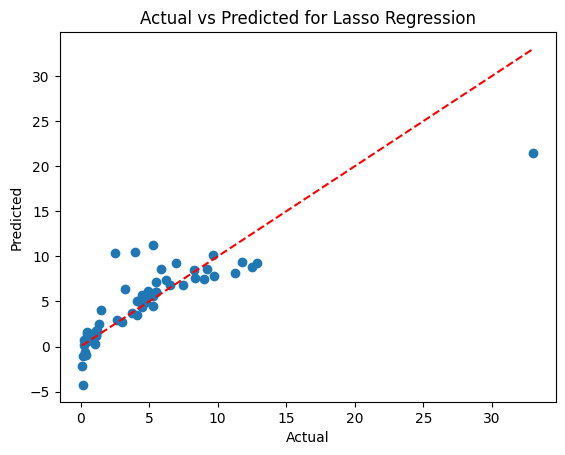

In [340]:
plt.scatter(y_test,lasso_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted for Lasso Regression')
plt.show()

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
R2_score = r2_score(y_test,lasso_pred)
MAE = mean_absolute_error(y_test,lasso_pred)
RMSE = np.sqrt(mean_squared_error(y_test,lasso_pred))
print(f"R2 suqare : {R2_score}")
print(f"MAE : {MAE}")
print(f"RMSE : {RMSE}")

R2 suqare : 0.742339315344769
MAE : 1.5365393753237737
RMSE : 2.5769665092850116
